# Delays are all you need 

This is a notebook to reproduce the [Delays are all you need](https://verzep.github.io/Takens/) page. Besides, I will also repeat these things on Mackey-Glass data to see what attractor it can show.

In [8]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import plotly.graph_objects as go

## data generation

Totally 12000 time steps, range from 0 to 12000

### Lorenz system

stored in ```y_l```, an ```np.array``` with dimension ```(3,12000)```

time stored in ```t```

In [9]:
# Define the Lorenz system of differential equations
def lorenz(t, y, sigma, rho, beta):
    dydt = [sigma * (y[1] - y[0]),
            y[0] * (rho - y[2]) - y[1],
            y[0] * y[1] - beta * y[2]]
    return dydt

# Set the parameters
sigma = 10.0
rho = 28.0
beta = 8.0 / 3.0

# Set the initial conditions
initial_conditions = [1.0, 0.0, 20.0]

# Set the time span for integration
t_span = (0, 100)
t_eval = np.linspace(t_span[0], t_span[1], 12000)

# Solve the system of differential equations
sol = solve_ivp(lorenz, 
                t_span, 
                initial_conditions, 
                args=(sigma, rho, beta), 
                t_eval=t_eval
            )

# Extract the solution
y_l = sol.y
t = sol.t

In [10]:
fig = go.Figure(data=[go.Scatter3d(
    x=y_l[0], y=y_l[1], z=y_l[2],
    mode='lines',
    line=dict(width=2, color='rgba(0,0,255,0.3)')
)])
fig.update_layout(title='Lorenz Attractor')
fig.show()

### MG data

stored in ```y_mg```, an ```np.array``` with dimension ```12000```

In [11]:
def MG_generate_interp(gamma=0.1,beta=0.2,tau=60,theta=1,n=10,x0=1,N=2000000,delta=0.01):
  def MG_eq (x,x_pre):
    return x_pre * beta * (theta**n)/(theta**n+x_pre**n)-gamma*x

  def MG_rk4(x,x_pre,x_pre_f):
    interplot = (x_pre+x_pre_f)/2
    k1 = MG_eq(x,x_pre)
    k2 = MG_eq(x+delta*k1/2,interplot)
    k3 = MG_eq(x+delta*k2/2,interplot)
    k4 = MG_eq(x+delta*k3,x_pre_f)
    return x+delta*(k1+2*k2+2*k3+k4)/6

  past_len = int(np.floor(tau/delta))
  x_past = np.zeros(past_len+N+1)+0.1
  x = x0
  X = np.zeros(N+1)
  T = np.zeros(N+1)
  time = 0

  for i in range(N+1):
    X[i] = x
    x_pre = x_past[i]
    x_pre_f = x_past[i+1]
    x_delta = MG_rk4(x=x,x_pre=x_pre,x_pre_f = x_pre_f)
    x_past[i+past_len] = x_delta
    T[i] = time
    time += delta
    x = x_delta

  interval  = int(np.floor(1/delta))
  T,X = T[::interval],X[::interval]
  return T,X

_,y_mg = MG_generate_interp(N = 12000000,tau = 30,delta = 0.001)

y_mg = np.array(y_mg)[1:]

## delay embeddings

setting delay embeddings with 20 delay steps and each delay with 1 steps.

delay embeddins of x from lorenz system stored in ```de_l```, an ```np.array``` with dimension ```(11981,20)```

delay embeddins of x from l MGdata stored in ```de_mg```, an ```np.array``` with dimension ```(11981,20)```

In [12]:
def delay_embedding(data, d, tau):
    N = len(data)
    indices = np.arange(d) * tau + np.arange(N - (d - 1) * tau)[:, None]
    return data[indices]

In [13]:
de_l = delay_embedding(y_l[0], 20, 1)
de_l = np.array(de_l)

In [14]:
de_mg = delay_embedding(y_mg, 20, 1)
de_mg = np.array(de_mg)

## SVD of embedded data

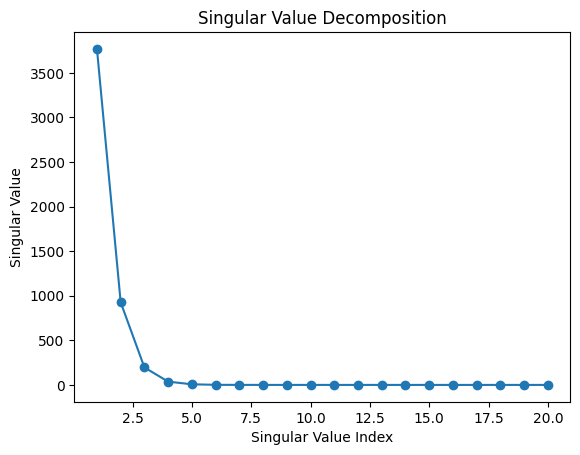

In [15]:
U, S, vh = np.linalg.svd(de_l.T)
plt.plot(range(1, len(S)+1), S, marker='o')
plt.xlabel("Singular Value Index")
plt.ylabel("Singular Value")
plt.title("Singular Value Decomposition")
plt.show()

In [17]:
fig = go.Figure(data=[go.Scatter3d(
    x=vh[0], y=vh[1], z=vh[2],
    mode='lines',
    line=dict(width=2, color='rgba(0,0,255,0.3)')
)])
fig.update_layout(title='Lorenz attractor revealed from one dimensional time series')
fig.show()


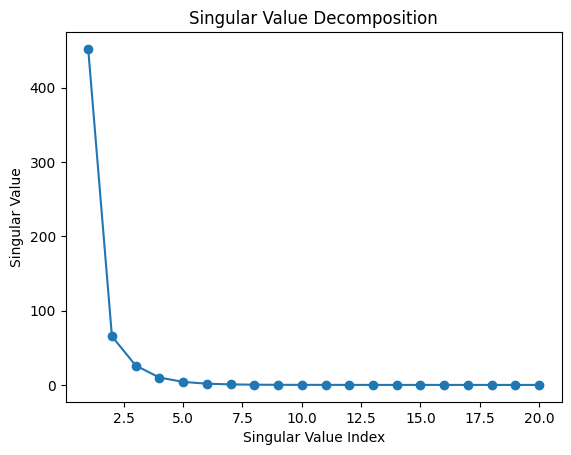

In [18]:
U, S, vh = np.linalg.svd(de_mg.T)
plt.plot(range(1, len(S)+1), S, marker='o')
plt.xlabel("Singular Value Index")
plt.ylabel("Singular Value")
plt.title("Singular Value Decomposition")
plt.show()

In [19]:
fig = go.Figure(data=[go.Scatter3d(
    x=vh[0], y=vh[1], z=vh[2],
    mode='lines',
    line=dict(width=2, color='rgba(0,0,255,0.3)')
)])
fig.update_layout(title='attractor revealed from Mackey Glass time series')
fig.show()


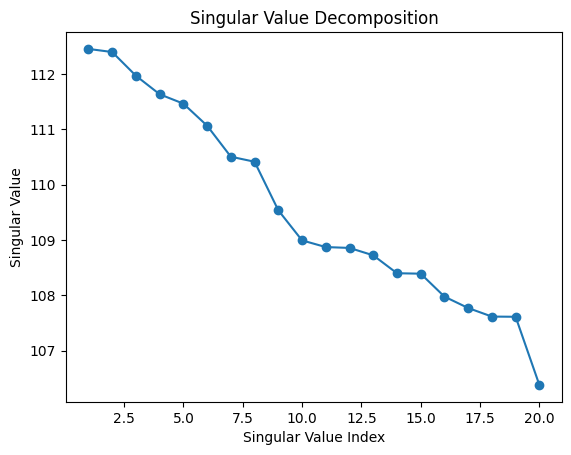

In [ ]:
wn = np.random.normal(0, 1, 12000)

de_wn = delay_embedding(wn, 20, 1)

U, S, vh = np.linalg.svd(de_wn.T)
plt.plot(range(1, len(S)+1), S, marker='o')
plt.xlabel("Singular Value Index")
plt.ylabel("Singular Value")
plt.title("Singular Value Decomposition")
plt.show()

In [22]:
fig = go.Figure(data=[go.Scatter3d(
    x=vh[0], y=vh[1], z=vh[2],
    mode='lines',
    line=dict(width=2, color='rgba(0,0,255,0.3)')
)])
fig.update_layout(title='attractor revealed from white noise time series')
fig.show()